<a href="https://colab.research.google.com/github/brandy99swords/AIML2013_CV/blob/main/week2%20/%20lab1_edge%20detection%20blurring%20kernels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

!pip install opencv-python

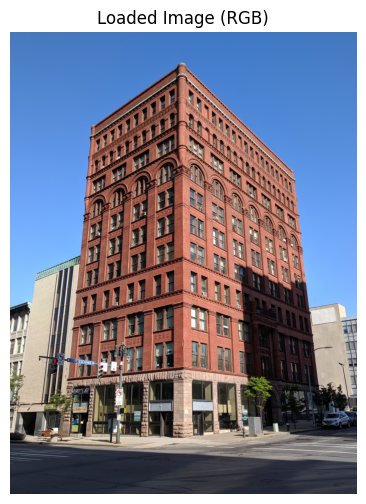

In [ ]:
!wget -q -O wilder_building.jpg https://upload.wikimedia.org/wikipedia/commons/4/45/WilderBuildingSummerSolstice.jpg

image = cv2.imread('wilder_building.jpg')

if image is None:
    print("Error: Could not load image. Please check the path and URL.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.imshow(image_rgb)
    plt.title('Loaded Image (RGB)')
    plt.axis('off')
    plt.show()

Image Shape: (4048, 3036, 3)
Image Data Type: uint8


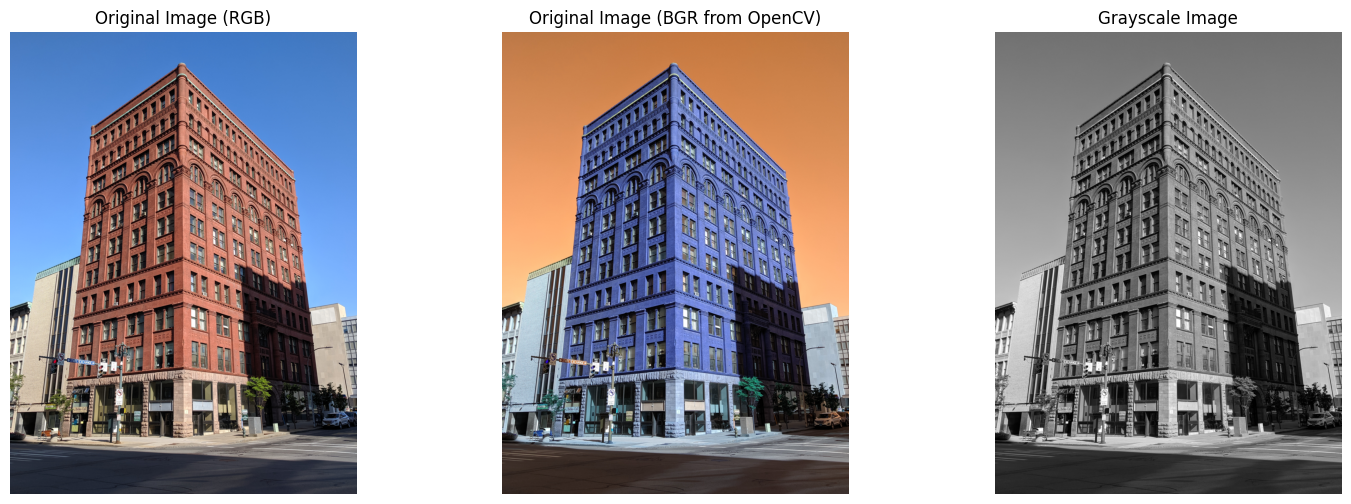

In [ ]:
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(image_rgb)
    plt.title('Original Image (RGB)')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(image)
    plt.title('Original Image (BGR from OpenCV)')
    plt.axis('off')

    print(f"Image Shape: {image.shape}")
    print(f"Image Data Type: {image.dtype}")

    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    plt.subplot(1, 3, 3)
    plt.imshow(gray_image, cmap='gray')
    plt.title('Grayscale Image')
    plt.axis('off')

    plt.show()

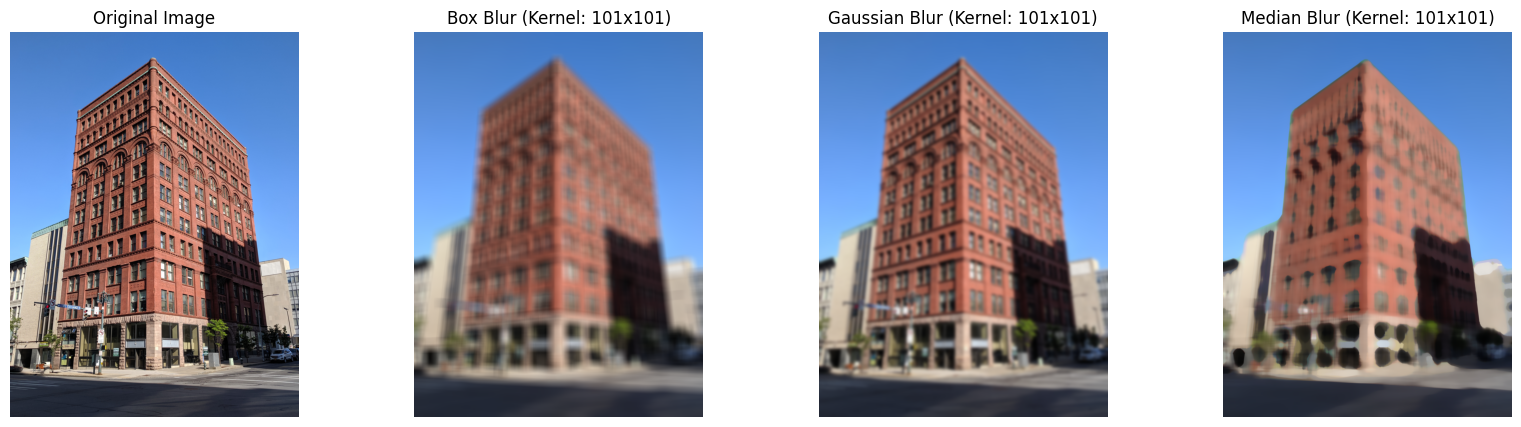

In [ ]:
kernel_size = 101

box_blurred_image = cv2.blur(image, (kernel_size, kernel_size))

gaussian_blurred_image = cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)

median_blurred_image = cv2.medianBlur(image, kernel_size)

original_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
box_blurred_rgb = cv2.cvtColor(box_blurred_image, cv2.COLOR_BGR2RGB)
gaussian_blurred_rgb = cv2.cvtColor(gaussian_blurred_image, cv2.COLOR_BGR2RGB)
median_blurred_rgb = cv2.cvtColor(median_blurred_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(original_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(box_blurred_rgb)
plt.title(f'Box Blur (Kernel: {kernel_size}x{kernel_size})')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(gaussian_blurred_rgb)
plt.title(f'Gaussian Blur (Kernel: {kernel_size}x{kernel_size})')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(median_blurred_rgb)
plt.title(f'Median Blur (Kernel: {kernel_size}x{kernel_size})')
plt.axis('off')

plt.show()

### Blurring with Kernels

Blurring images means making them look softer by changing pixel colors based on their neighbors. We use a 'kernel,' which is like a small recipe, to decide how to mix these colors. Imagine sliding this kernel over every pixel; that's 'convolution.'

1.  **Box Blur:** Simply averages all pixel colors under the kernel. It makes everything evenly blurry, a bit like squinting.
2.  **Gaussian Blur:** A smarter average, giving more importance to pixels closer to the center of the kernel. This creates a super smooth, natural-looking blur, good for softening images.
3.  **Median Blur:** Instead of averaging, it picks the middle color value from all pixels under the kernel. This is fantastic for getting rid of noisy dots while keeping edges pretty clear.

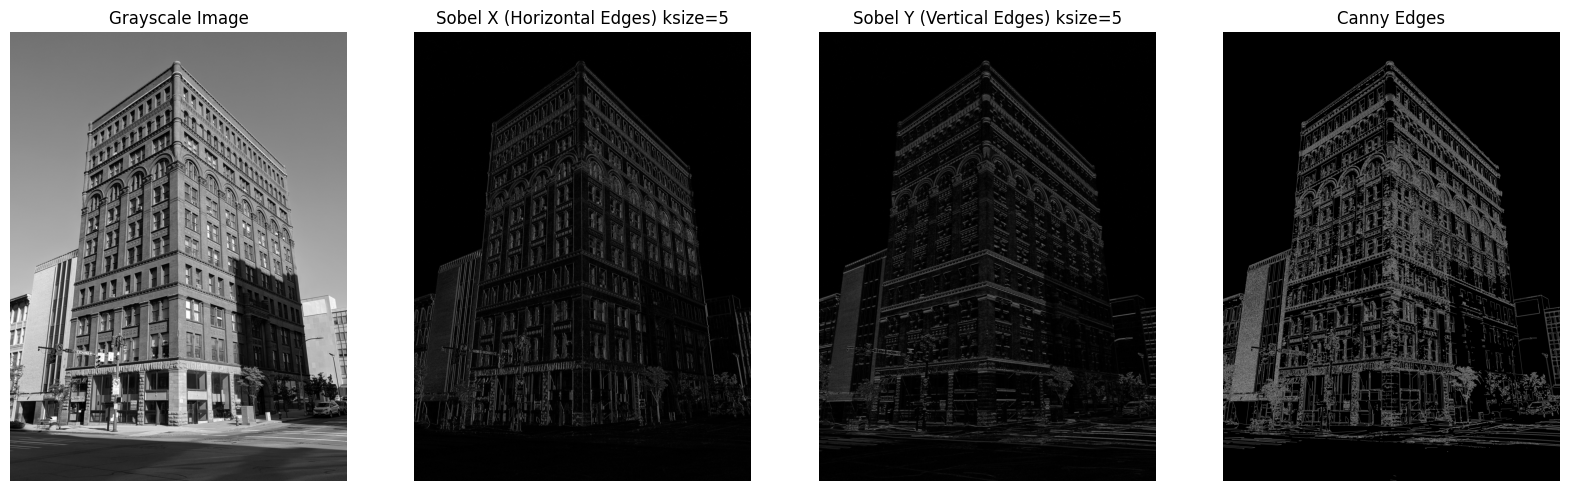

In [ ]:
    sobel_ksize = 5

    sobelx = cv2.Sobel(gray_image, cv2.CV_64F, 1, 0, ksize=sobel_ksize)
    sobelx = cv2.normalize(np.absolute(sobelx), None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

    sobely = cv2.Sobel(gray_image, cv2.CV_64F, 0, 1, ksize=sobel_ksize)
    sobely = cv2.normalize(np.absolute(sobely), None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

    canny_edges = cv2.Canny(gray_image, 100, 200)

    plt.figure(figsize=(20, 8))

    plt.subplot(1, 4, 1)
    plt.imshow(gray_image, cmap='gray')
    plt.title('Grayscale Image')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(sobelx, cmap='gray')
    plt.title(f'Sobel X (Horizontal Edges) ksize={sobel_ksize}')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(sobely, cmap='gray')
    plt.title(f'Sobel Y (Vertical Edges) ksize={sobel_ksize}')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(canny_edges, cmap='gray')
    plt.title('Canny Edges')
    plt.axis('off')

    plt.show()

### Edge Detection with Filters

Edge detection is about finding sudden changes in pixel brightness within an image. These 'edges' often correspond to the boundaries of objects or regions.

1.  **Sobel Filter:** This filter is like a 'difference detector.' It uses two small kernels, one for finding changes in brightness horizontally (left-to-right) and another for vertical changes (top-to-bottom). If a kernel moves over an area where pixels suddenly go from dark to light, it gives a high value, highlighting that as an edge. It's good for picking out the main directional edges.
2.  **Canny Edge Detection:** This is a more sophisticated, multi-step process for finding robust and clean edges:
    *   **Noise Reduction:** First, it applies a slight blur to smooth out noise, preventing false edges.
    *   **Gradient Calculation:** Then, it finds the intensity gradients (similar to Sobel), determining the strength and direction of brightness changes.
    *   **Non-maximum Suppression:** It thins the edges, ensuring they are only one pixel wide, which makes them sharp.
    *   **Hysteresis Thresholding:** Finally, it uses two thresholds (a strong and a weak one) to decide which edges are real. It keeps strong edges and includes weaker ones only if they are connected to strong ones. This helps create continuous and reliable edge maps.

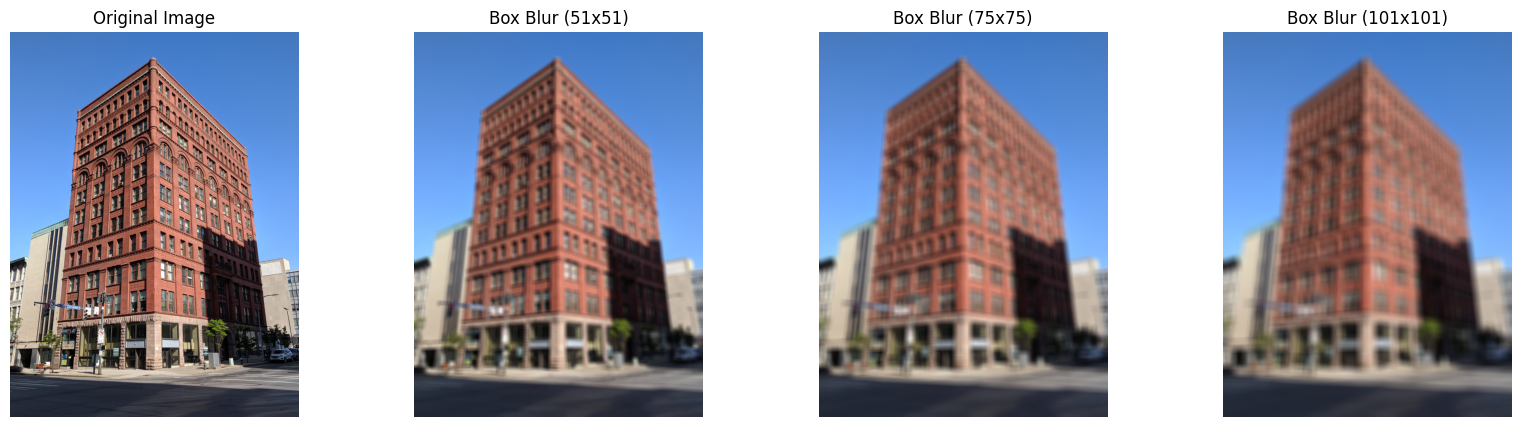

In [ ]:
kernel_sizes = [51, 75, 101]

plt.figure(figsize=(20, 5))

plt.subplot(1, len(kernel_sizes) + 1, 1)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')

for i, k_size in enumerate(kernel_sizes):
    box_blurred = cv2.blur(image, (k_size, k_size))
    box_blurred_rgb = cv2.cvtColor(box_blurred, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(kernel_sizes) + 1, i + 2)
    plt.imshow(box_blurred_rgb)
    plt.title(f'Box Blur ({k_size}x{k_size})')
    plt.axis('off')

plt.show()

### Effect of Kernel Size on Blurring

As the kernel size increases, the image becomes progressively blurrier. This is because a larger kernel considers a wider area of neighboring pixels when calculating the new value for each pixel. This results in a more pronounced averaging effect across a larger region, leading to a softer, less detailed image.

**Reflection**

Working through this assignment gave me a new perspective on how images can be analyzed at a pixel level. I am used to evaluating images closely, considering color, lighting, and how those elements affect selections and visual interpretation. I have always been curious about the programming and mathematical processes behind image manipulation, but I had not previously explored how filters like blurs or edge detection actually work. This assignment allowed me to connect the visual results I am familiar with to the underlying calculations that create them.

The Sobel X and Sobel Y filters were particularly enlightening. These filters compare pixel intensity horizontally and vertically to identify edges. The directional differences they revealed often aligned with lighting and shadows in the image, such as along windows or other surfaces where light falls unevenly. Initially, some of these differences appeared to me like traditional highlights and shadows, but I now understand that they are mathematically derived from changes in pixel intensity along specific directions. Blur filters also highlighted how the averaging of neighboring pixels can soften an image, which I had seen in Photoshop but never fully considered from a computational perspective.

If I were completing this assignment again, I would work with a smaller image or adjust the resolution before processing it. I used a random image from the web and did not consider the resolution, which made it more difficult to clearly observe the filter effects. Reducing the size in code or a graphics program would have made the results easier to analyze.

Overall, this assignment deepened my understanding of how machines “see” images differently from humans and gave me a practical connection between the visual effects I use daily and the mathematical processes that produce them.